# Supplementary McFaline benchmark metrics

Reproduces McFaline seen and unseen perturbation benchmark panels.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## Benchmark summary


Seen perturbation setting
Median MSE on DEGs:
TranScouter    0.323694
scGen          0.311707
Avg            0.568639

Median DMR on DEGs:
TranScouter    0.35
scGen          0.35
Avg            0.45


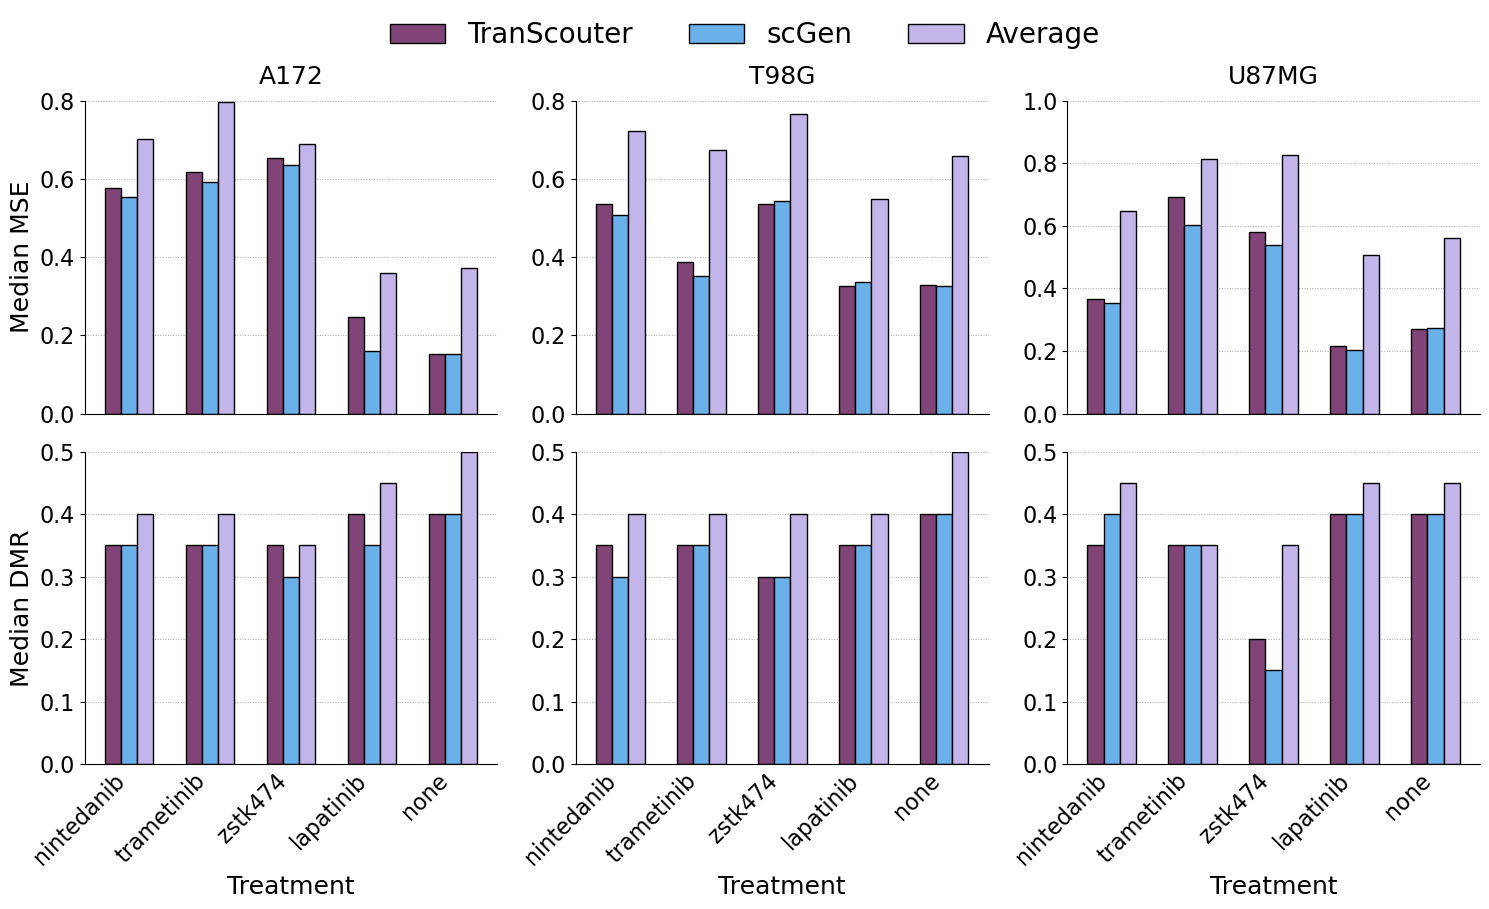

Unseen perturbation setting
Median MSE on DEGs:
TranScouter    0.319258
Correlation    0.322701
Avg            0.566670

Median DMR on DEGs:
TranScouter    0.35
Correlation    0.50
Avg            0.45


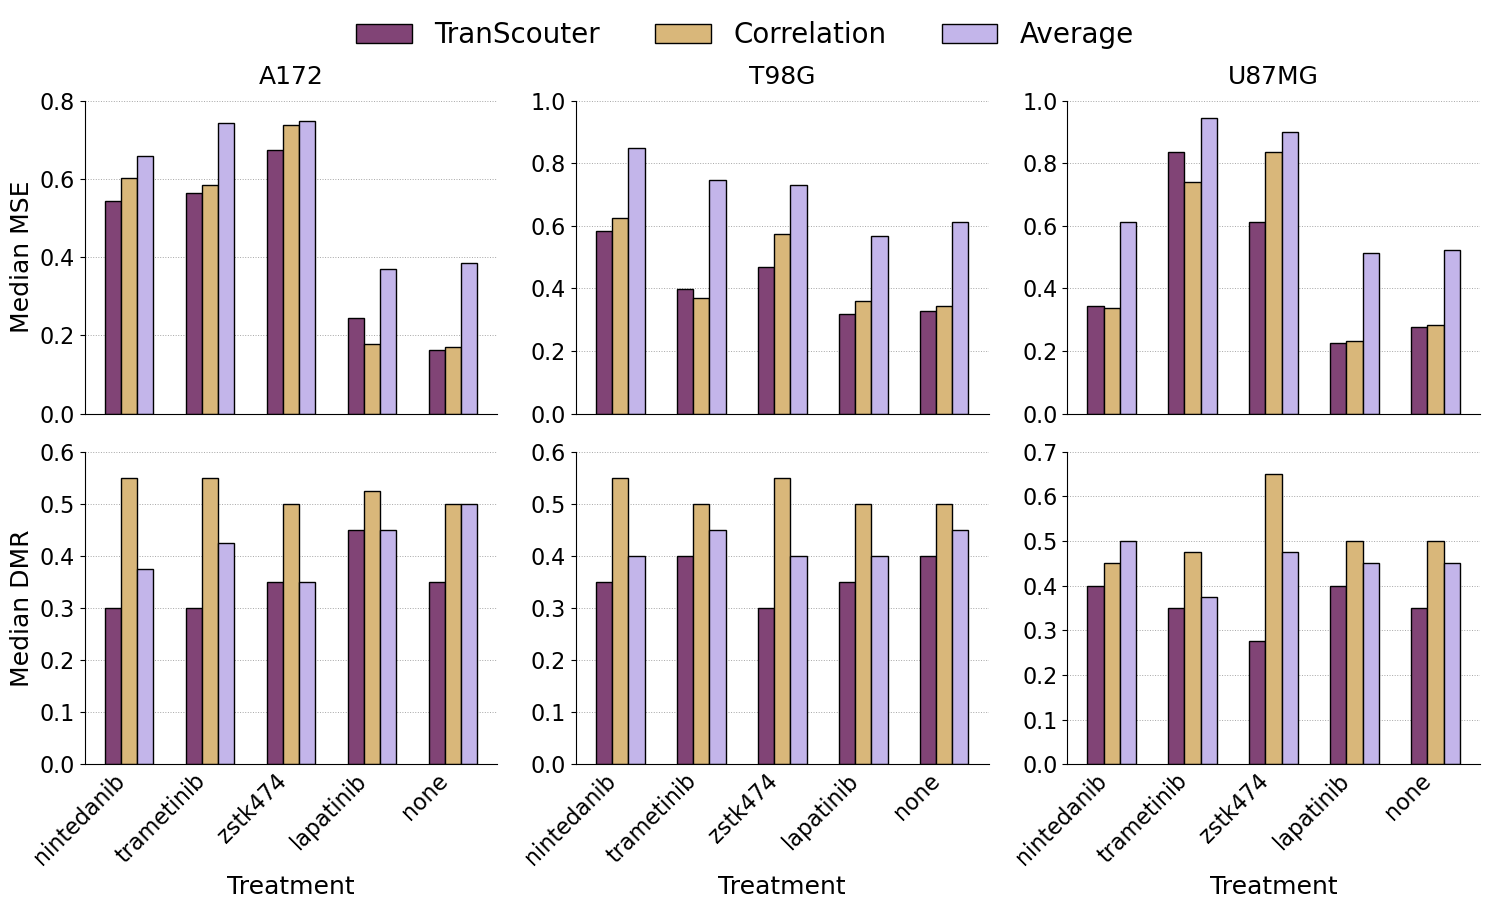

In [2]:
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
SCENARIOS = {
    "seen": {
        "label": "Seen perturbation setting",
        "results_path": "results/collected/mcfaline/seen_pred_results.pkl",
        "method_cols": ["TranScouter", "scGen", "Avg"],
        "display_names": ["TranScouter", "scGen", "Average"],
        "save_prefix": "figures/supplement/output/SeenPerturb_mcfaline",
    },
    "unseen": {
        "label": "Unseen perturbation setting",
        "results_path": "results/collected/mcfaline/unseen_pred_results.pkl",
        "method_cols": ["TranScouter", "Correlation", "Avg"],
        "display_names": ["TranScouter", "Correlation", "Average"],
        "save_prefix": "figures/supplement/output/UnseenPerturb_mcfaline",
    },
}

method_colors = {
    "TranScouter": "#814476",
    "Avg":         "#c3b5ea",
    "scGen":       "#6ab1e9",
    "trVAE":       "#50acad",
    "Correlation": "#d9b77a",
    "CellOracle":  "#c98f8f",
}
# fmt: on

ad = sc.read_h5ad("data/mcfaline/processed/mcfaline.h5ad")
top_degs_names = ad.uns["top_degs_names"]


def compute_metrics(results, method_cols):
    true = results["True"]
    ctrl = results["Ctrl"]
    preds = {name: results[name] for name in method_cols}
    metrics = {
        "MSE_degs": {name: {} for name in preds},
        "DMR_degs": {name: {} for name in preds},
    }

    for cov_pert in preds["TranScouter"].index:
        degs = top_degs_names[cov_pert]
        true_i = true.loc[cov_pert]
        ctrl_i = ctrl.loc[cov_pert.rsplit("_", 1)[0] + "_control"]

        for name, df in preds.items():
            if cov_pert not in df.index:
                continue
            pred_i = df.loc[cov_pert]
            if np.all(np.isnan(pred_i)):
                continue
            if len(degs) > 0:
                metrics["MSE_degs"][name][cov_pert] = mse(pred_i[degs], true_i[degs])
                metrics["DMR_degs"][name][cov_pert] = np.mean(
                    np.sign(pred_i[degs] - ctrl_i[degs]) != np.sign(true_i[degs] - ctrl_i[degs])
                )

    return (
        pd.DataFrame(metrics["MSE_degs"]),
        pd.DataFrame(metrics["DMR_degs"]),
    )


def plot_celltype_panels_grid(rows, colors, method_cols, display_names, save_prefix=None):
    def _prep(df):
        df = df.assign(covariate=df.index.to_series().str.split("_", expand=True)[0])
        df[["celltype", "treatment"]] = df.covariate.str.split("+", expand=True)
        df["celltype"] = df["celltype"].str.upper()
        return df

    prepped = [(_prep(df), m, y) for df, m, y in rows]
    celltypes = prepped[0][0]["celltype"].unique()
    treatments = prepped[0][0]["treatment"].unique()
    n_rows, n_cols = len(prepped), len(celltypes)

    plt.rcParams.update({
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(15, 4.5 * n_rows), sharex=True
    )
    axes = np.atleast_2d(axes)

    for r, (df, metric_name, ymin) in enumerate(prepped):
        agg = df.groupby(["celltype", "treatment"], observed=False)[method_cols].median().reset_index()

        for c, ct in enumerate(celltypes):
            ax = axes[r, c]
            sub = (
                agg[agg["celltype"] == ct]
                .set_index("treatment")
                .reindex(treatments)
            )

            sub[method_cols].plot(
                kind="bar", ax=ax, color=colors,
                width=0.6, edgecolor="black", legend=False,
            )

            yticks = ax.get_yticks()
            ymax = yticks[-2] if sub[method_cols].values.max() <= yticks[-2] else yticks[-1]
            ymin_val = sub[method_cols].values.min() if ymin == "adap" else ymin
            ax.set_ylim(ymin_val, ymax)
            ax.yaxis.grid(True, linestyle=":", linewidth=0.7, color="gray", alpha=0.7)
            ax.set_axisbelow(True)
            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)

            if r == 0:
                ax.set_title(f"{ct}", pad=12)
            ax.set_ylabel(f"Median {metric_name}" if c == 0 else "")
            ax.set_xlabel("Treatment" if r == n_rows - 1 else "")
            ax.set_xticklabels(sub.index, rotation=45, ha="right")
            ax.tick_params(axis="x", length=0)

    handles = [mpatches.Patch(facecolor=c, edgecolor="black") for c in colors]
    fig.legend(
        handles, display_names,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(display_names),
        fontsize=20,
        frameon=False,
    )

    plt.tight_layout(rect=(0, 0, 1, 0.96))
    if globals().get("SAVE_FIGURES", False) and save_prefix:
        filename = f"{save_prefix}.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Saved: {filename}")
    plt.show()


for scenario, cfg in SCENARIOS.items():
    print(cfg["label"])
    with open(cfg["results_path"], "rb") as f:
        results = pickle.load(f)

    colors = [method_colors[name] for name in cfg["method_cols"]]
    MSE_degs, DMR_degs = compute_metrics(results, cfg["method_cols"])

    print("Median MSE on DEGs:")
    print(MSE_degs.median().to_string())
    print()
    print("Median DMR on DEGs:")
    print(DMR_degs.median().to_string())

    plot_celltype_panels_grid(
        [(MSE_degs, "MSE", 0), (DMR_degs, "DMR", 0)],
        colors,
        cfg["method_cols"],
        cfg["display_names"],
        save_prefix=cfg["save_prefix"],
    )